In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)

data_path = Path(
    r"C:\Users\GIA NGUYEN\OneDrive\Máy tính\Ecommerce_Olist_Analysis\data\raw"
)

customers = pd.read_csv(data_path / "olist_customers_dataset.csv")
orders = pd.read_csv(data_path / "olist_orders_dataset.csv")
order_items = pd.read_csv(data_path / "olist_order_items_dataset.csv")
payments = pd.read_csv(data_path / "olist_order_payments_dataset.csv")
reviews = pd.read_csv(data_path / "olist_order_reviews_dataset.csv")
products = pd.read_csv(data_path / "olist_products_dataset.csv")
sellers = pd.read_csv(data_path / "olist_sellers_dataset.csv")
geolocation = pd.read_csv(data_path / "olist_geolocation_dataset.csv")
category_translation = pd.read_csv(
    data_path / "product_category_name_translation.csv"
)

print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Order items:", order_items.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)
print("Products:", products.shape)
print("Sellers:", sellers.shape)
print("Geolocation:", geolocation.shape)
print("Category translation:", category_translation.shape)

Customers: (99441, 5)
Orders: (99441, 8)
Order items: (112650, 7)
Payments: (103886, 5)
Reviews: (99224, 7)
Products: (32951, 9)
Sellers: (3095, 4)
Geolocation: (1000163, 5)
Category translation: (71, 2)


In [2]:
customers_clean = customers.copy()
orders_clean = orders.copy()
order_items_clean = order_items.copy()
payments_clean = payments.copy()
reviews_clean = reviews.copy()
products_clean = products.copy()
sellers_clean = sellers.copy()
geolocation_clean = geolocation.copy()
category_translation_clean = category_translation.copy()

In [3]:
order_date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in order_date_columns:
    orders_clean[column] = pd.to_datetime(
        orders_clean[column],
        errors="coerce"
    )

review_date_columns = [
    "review_creation_date",
    "review_answer_timestamp"
]

for column in review_date_columns:
    reviews_clean[column] = pd.to_datetime(
        reviews_clean[column],
        errors="coerce"
    )

order_items_clean["shipping_limit_date"] = pd.to_datetime(
    order_items_clean["shipping_limit_date"],
    errors="coerce"
)

In [4]:
orders_clean[order_date_columns].dtypes

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [5]:
rows_before = len(geolocation_clean)

geolocation_clean = geolocation_clean.drop_duplicates()

rows_after = len(geolocation_clean)

print("Số dòng trước:", rows_before)
print("Số dòng sau:", rows_after)
print("Số dòng đã xóa:", rows_before - rows_after)

Số dòng trước: 1000163
Số dòng sau: 738332
Số dòng đã xóa: 261831


In [6]:
products_clean = products_clean.merge(
    category_translation_clean,
    on="product_category_name",
    how="left"
)

In [7]:
products_clean["product_category_name"] = (
    products_clean["product_category_name"].fillna("unknown")
)

products_clean["product_category_name_english"] = (
    products_clean["product_category_name_english"].fillna("unknown")
)

In [8]:
products_clean[
    ["product_category_name", "product_category_name_english"]
].isnull().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

In [9]:
delivery_missing_by_status = (
    orders_clean[
        orders_clean["order_delivered_customer_date"].isna()
    ]
    ["order_status"]
    .value_counts()
)

delivery_missing_by_status

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

In [10]:
delivered_without_date = orders_clean[
    (orders_clean["order_status"] == "delivered") &
    (orders_clean["order_delivered_customer_date"].isna())
]

print(
    "Delivered orders without delivery date:",
    len(delivered_without_date)
)

Delivered orders without delivery date: 8


In [11]:
zero_payments = payments_clean[
    payments_clean["payment_value"] <= 0
]

zero_payments

,order_id,payment_sequential,payment_type,payment_installments,payment_value
19922,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.0
36822,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.0
43744,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.0
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
62674,45ed6e85398a87c253db47c2d9f48216,3,voucher,1,0.0
77885,fa65dad1b0e818e3ccc5cb0e39231352,13,voucher,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0
100766,b23878b3e8eb4d25a158f57d96331b18,4,voucher,1,0.0


In [12]:
zero_payments["payment_type"].value_counts(dropna=False)

payment_type
voucher        6
not_defined    3
Name: count, dtype: int64

In [13]:
zero_payment_orders = zero_payments.merge(
    orders_clean[
        ["order_id", "order_status", "order_purchase_timestamp"]
    ],
    on="order_id",
    how="left"
)

zero_payment_orders

,order_id,payment_sequential,payment_type,payment_installments,payment_value,order_status,order_purchase_timestamp
0,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.0,delivered,2018-01-24 23:24:14
1,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.0,shipped,2017-04-20 12:45:34
2,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.0,delivered,2017-10-26 23:51:35
3,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0,canceled,2018-09-03 14:14:25
4,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0,canceled,2018-08-28 15:26:39
5,45ed6e85398a87c253db47c2d9f48216,3,voucher,1,0.0,delivered,2017-06-08 21:18:45
6,fa65dad1b0e818e3ccc5cb0e39231352,13,voucher,1,0.0,shipped,2017-04-20 12:45:34
7,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0,canceled,2018-08-28 20:05:14
8,b23878b3e8eb4d25a158f57d96331b18,4,voucher,1,0.0,delivered,2017-05-27 19:20:24


In [14]:
zero_payment_details = zero_payment_orders.merge(
    order_items_clean[
        ["order_id", "price", "freight_value"]
    ],
    on="order_id",
    how="left"
)

zero_payment_details[
    [
        "order_id",
        "payment_type",
        "payment_value",
        "order_status",
        "price",
        "freight_value"
    ]
]

,order_id,payment_type,payment_value,order_status,price,freight_value
0,8bcbe01d44d147f901cd3192671144db,voucher,0.0,delivered,59.00,15.16
1,fa65dad1b0e818e3ccc5cb0e39231352,voucher,0.0,shipped,392.55,65.44
2,6ccb433e00daae1283ccc956189c82ae,voucher,0.0,delivered,94.00,28.04
3,4637ca194b6387e2d538dc89b124b0ee,not_defined,0.0,canceled,NaN,NaN
4,00b1cb0320190ca0daa2c88b35206009,not_defined,0.0,canceled,NaN,NaN
5,45ed6e85398a87c253db47c2d9f48216,voucher,0.0,delivered,56.99,14.15
6,fa65dad1b0e818e3ccc5cb0e39231352,voucher,0.0,shipped,392.55,65.44
7,c8c528189310eaa44a745b8d9d26908b,not_defined,0.0,canceled,NaN,NaN
8,b23878b3e8eb4d25a158f57d96331b18,voucher,0.0,delivered,135.30,36.27


In [15]:
delivered_orders = orders_clean[
    orders_clean["order_status"] == "delivered"
].copy()

print("Toàn bộ đơn hàng:", len(orders_clean))
print("Đơn đã giao:", len(delivered_orders))

Toàn bộ đơn hàng: 99441
Đơn đã giao: 96478


In [16]:
order_items_agg = (
    order_items_clean
    .groupby("order_id", as_index=False)
    .agg(
        total_product_value=("price", "sum"),
        total_freight_value=("freight_value", "sum"),
        number_of_items=("order_item_id", "count")
    )
)

order_items_agg.head()

,order_id,total_product_value,total_freight_value,number_of_items
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,1
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,1
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,1
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,1


In [17]:
payments_agg = (
    payments_clean
    .groupby("order_id", as_index=False)
    .agg(
        total_payment_value=("payment_value", "sum"),
        payment_records=("payment_sequential", "count"),
        payment_methods=("payment_type", "nunique"),
        max_installments=("payment_installments", "max")
    )
)

payments_agg.head()

,order_id,total_payment_value,payment_records,payment_methods,max_installments
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,1,1,2
1,00018f77f2f0320c557190d7a144bdd3,259.83,1,1,3
2,000229ec398224ef6ca0657da4fc703e,216.87,1,1,5
3,00024acbcdf0a6daa1e931b038114c75,25.78,1,1,2
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,1,1,3


In [18]:
print("Số dòng:", len(payments_agg))
print("Số order_id duy nhất:", payments_agg["order_id"].nunique())
print("Số order_id bị trùng:", payments_agg["order_id"].duplicated().sum())

Số dòng: 99440
Số order_id duy nhất: 99440
Số order_id bị trùng: 0


In [19]:
analysis_df = (
    delivered_orders
    .merge(
        order_items_agg,
        on="order_id",
        how="left",
        validate="one_to_one"
    )
    .merge(
        payments_agg,
        on="order_id",
        how="left",
        validate="one_to_one"
    )
)

analysis_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_product_value,total_freight_value,number_of_items,total_payment_value,payment_records,payment_methods,max_installments
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,29.99,8.72,1,38.71,3.0,2.0,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,118.70,22.76,1,141.46,1.0,1.0,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,159.90,19.22,1,179.12,1.0,1.0,3.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,45.00,27.20,1,72.20,1.0,1.0,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,19.90,8.72,1,28.62,1.0,1.0,1.0


In [20]:
print("Số đơn đã giao:", len(delivered_orders))
print("Số dòng sau khi ghép:", len(analysis_df))
print("Số order_id duy nhất:", analysis_df["order_id"].nunique())
print("Số order_id trùng:", analysis_df["order_id"].duplicated().sum())

Số đơn đã giao: 96478
Số dòng sau khi ghép: 96478
Số order_id duy nhất: 96478
Số order_id trùng: 0


In [21]:
columns_to_check = [
    "total_product_value",
    "total_freight_value",
    "number_of_items",
    "total_payment_value",
    "payment_records",
    "payment_methods",
    "max_installments"
]

analysis_df[columns_to_check].isnull().sum()

total_product_value    0
total_freight_value    0
number_of_items        0
total_payment_value    1
payment_records        1
payment_methods        1
max_installments       1
dtype: int64

In [22]:
analysis_df["calculated_order_value"] = (
    analysis_df["total_product_value"]
    + analysis_df["total_freight_value"]
)

analysis_df["payment_difference"] = (
    analysis_df["total_payment_value"]
    - analysis_df["calculated_order_value"]
)

In [23]:
analysis_df["payment_difference"].describe()

count    96477.000000
mean         0.029349
std          1.138706
min        -51.620000
25%          0.000000
50%          0.000000
75%          0.000000
max        182.810000
Name: payment_difference, dtype: float64

In [24]:
analysis_df["payment_matches"] = np.isclose(
    analysis_df["total_payment_value"],
    analysis_df["calculated_order_value"],
    atol=1
)

analysis_df["payment_matches"].value_counts()

payment_matches
True     96231
False      247
Name: count, dtype: int64

In [25]:
payment_mismatches = (
    analysis_df[analysis_df["payment_matches"] == False]
    .sort_values("payment_difference", key=abs, ascending=False)
)

payment_mismatches[
    [
        "order_id",
        "total_product_value",
        "total_freight_value",
        "calculated_order_value",
        "total_payment_value",
        "payment_difference"
    ]
].head(10)

,order_id,total_product_value,total_freight_value,calculated_order_value,total_payment_value,payment_difference
11458,ce6d150fb29ada17d2082f4847107665,1299.00,104.66,1403.66,1586.47,182.81
47235,6e5fe7366a2e1bfbf3257dba0af1267f,179.19,108.72,287.91,406.92,119.01
68752,70b742795bc441e94a44a084b6d9ce7a,269.99,196.94,466.93,578.82,111.89
32174,996c7e73600ad3723e8627ab7bef81e4,559.90,28.00,587.90,664.43,76.53
51423,70b7e94ea46d3e8b5bc12a50186edaf0,167.88,45.27,213.15,274.84,61.69
82872,bc2c82b0ef78d2252b6176d1972db7c9,165.00,77.01,242.01,303.02,61.01
91499,af9ffff2ce6b3defd34fd4c78857a379,395.65,17.52,413.17,466.97,53.80
30725,262118ce178bb3e4590a3adcf6d62e6b,119.80,57.94,177.74,126.12,-51.62
66757,bfdb5bbb06458d600a33d61f5f287472,297.00,51.93,348.93,394.36,45.43
8310,8d9c0dc8d5a2ce804f6b925d8f8e6c1d,209.80,44.65,254.45,293.89,39.44


In [26]:
analysis_df[
    [
        "total_product_value",
        "total_freight_value",
        "total_payment_value",
        "payment_difference"
    ]
].isna().sum()

total_product_value    0
total_freight_value    0
total_payment_value    1
payment_difference     1
dtype: int64

In [27]:
missing_payment_orders = analysis_df[
    analysis_df["total_payment_value"].isna()
]

missing_payment_orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_product_value,total_freight_value,number_of_items,total_payment_value,payment_records,payment_methods,max_installments,calculated_order_value,payment_difference,payment_matches
29811,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,134.97,8.49,3,NaN,NaN,NaN,NaN,143.46,NaN,False


In [28]:
valid_payment_mismatches = analysis_df[
    analysis_df["total_payment_value"].notna()
    & (~analysis_df["payment_matches"])
].copy()

print("Số đơn chênh lệch thực sự:", len(valid_payment_mismatches))

Số đơn chênh lệch thực sự: 246


In [29]:
valid_payment_mismatches["absolute_difference"] = (
    valid_payment_mismatches["payment_difference"].abs()
)

pd.cut(
    valid_payment_mismatches["absolute_difference"],
    bins=[1, 5, 10, 50, 100, float("inf")],
    labels=["1–5", "5–10", "10–50", "50–100", "Trên 100"]
).value_counts().sort_index()

absolute_difference
1–5         77
5–10        72
10–50       89
50–100       5
Trên 100     3
Name: count, dtype: int64

In [30]:

analysis_df["payment_quality"] = np.select(
    [
        analysis_df["total_payment_value"].isna(),
        analysis_df["payment_matches"]
    ],
    [
        "missing_payment",
        "matched"
    ],
    default="mismatch"
)

analysis_df["payment_quality"].value_counts()

payment_quality
matched            96231
mismatch             246
missing_payment        1
Name: count, dtype: int64

In [31]:
analysis_df["final_order_value"] = (
    analysis_df["total_payment_value"]
    .fillna(analysis_df["calculated_order_value"])
)

In [32]:
analysis_df[
    [
        "total_payment_value",
        "calculated_order_value",
        "final_order_value",
        "payment_quality"
    ]
].isna().sum()

total_payment_value       1
calculated_order_value    0
final_order_value         0
payment_quality           0
dtype: int64

In [33]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in date_columns:
    analysis_df[column] = pd.to_datetime(
        analysis_df[column],
        errors="coerce"
    )

analysis_df[date_columns].dtypes

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [34]:
analysis_df["purchase_year"] = (
    analysis_df["order_purchase_timestamp"].dt.year
)

analysis_df["purchase_month"] = (
    analysis_df["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

analysis_df["purchase_day"] = (
    analysis_df["order_purchase_timestamp"].dt.day_name()
)

analysis_df["purchase_hour"] = (
    analysis_df["order_purchase_timestamp"].dt.hour
)

analysis_df["day_type"] = np.where(
    analysis_df["order_purchase_timestamp"].dt.dayofweek < 5,
    "Weekday",
    "Weekend"
)

In [35]:
analysis_df["delivery_time_days"] = (
    analysis_df["order_delivered_customer_date"]
    - analysis_df["order_purchase_timestamp"]
).dt.total_seconds() / 86400

analysis_df["estimated_delivery_days"] = (
    analysis_df["order_estimated_delivery_date"]
    - analysis_df["order_purchase_timestamp"]
).dt.total_seconds() / 86400

analysis_df["delivery_delay_days"] = (
    analysis_df["order_delivered_customer_date"]
    - analysis_df["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

In [36]:
analysis_df["delivery_status"] = np.select(
    [
        analysis_df["delivery_delay_days"].isna(),
        analysis_df["delivery_delay_days"] > 0
    ],
    [
        "Unknown",
        "Late"
    ],
    default="On time"
)

In [37]:
analysis_df[
    [
        "purchase_year",
        "purchase_month",
        "purchase_day",
        "purchase_hour",
        "day_type",
        "delivery_time_days",
        "estimated_delivery_days",
        "delivery_delay_days",
        "delivery_status"
    ]
].head()

,purchase_year,purchase_month,purchase_day,purchase_hour,day_type,delivery_time_days,estimated_delivery_days,delivery_delay_days,delivery_status
0,2017,2017-10,Monday,10,Weekday,8.436574,15.544063,-7.107488,On time
1,2018,2018-07,Tuesday,20,Weekday,13.782037,19.137766,-5.355729,On time
2,2018,2018-08,Wednesday,8,Weekday,9.394213,26.639711,-17.245498,On time
3,2017,2017-11,Saturday,19,Weekend,13.208750,26.188819,-12.980069,On time
4,2018,2018-02,Tuesday,21,Weekday,2.873877,12.112049,-9.238171,On time


In [38]:
analysis_df["delivery_status"].value_counts(dropna=False)

delivery_status
On time    88644
Late        7826
Unknown        8
Name: count, dtype: int64

In [39]:
customers_clean.columns.tolist()

['customer_id',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state']

In [40]:
analysis_df = analysis_df.merge(
    customers_clean[
        [
            "customer_id",
            "customer_unique_id",
            "customer_city",
            "customer_state"
        ]
    ],
    on="customer_id",
    how="left",
    validate="many_to_one"
)

In [41]:
print("Số dòng sau khi ghép:", len(analysis_df))
print("Số order_id duy nhất:", analysis_df["order_id"].nunique())

analysis_df[
    [
        "order_id",
        "customer_id",
        "customer_unique_id",
        "customer_city",
        "customer_state"
    ]
].head()

Số dòng sau khi ghép: 96478
Số order_id duy nhất: 96478


,order_id,customer_id,customer_unique_id,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP


In [42]:
analysis_df[
    [
        "customer_unique_id",
        "customer_city",
        "customer_state"
    ]
].isna().sum()

customer_unique_id    0
customer_city         0
customer_state        0
dtype: int64

In [43]:
reviews_agg = (
    reviews_clean
    .groupby("order_id", as_index=False)
    .agg(
        average_review_score=("review_score", "mean"),
        number_of_reviews=("review_id", "nunique")
    )
)

reviews_agg.head()

,order_id,average_review_score,number_of_reviews
0,00010242fe8c5a6d1ba2dd792cb16214,5.0,1
1,00018f77f2f0320c557190d7a144bdd3,4.0,1
2,000229ec398224ef6ca0657da4fc703e,5.0,1
3,00024acbcdf0a6daa1e931b038114c75,4.0,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0,1


In [44]:
print("Số dòng:", len(reviews_agg))
print("Số order_id duy nhất:", reviews_agg["order_id"].nunique())
print("Số order_id trùng:", reviews_agg["order_id"].duplicated().sum())

Số dòng: 98673
Số order_id duy nhất: 98673
Số order_id trùng: 0


In [45]:
analysis_df = analysis_df.merge(
    reviews_agg,
    on="order_id",
    how="left",
    validate="one_to_one"
)

In [46]:
print("Số dòng sau khi ghép:", len(analysis_df))
print("Số order_id duy nhất:", analysis_df["order_id"].nunique())
print("Số đơn thiếu đánh giá:", analysis_df["average_review_score"].isna().sum())

analysis_df[
    [
        "order_id",
        "delivery_status",
        "delivery_time_days",
        "delivery_delay_days",
        "average_review_score",
        "number_of_reviews"
    ]
].head()

Số dòng sau khi ghép: 96478
Số order_id duy nhất: 96478
Số đơn thiếu đánh giá: 646


,order_id,delivery_status,delivery_time_days,delivery_delay_days,average_review_score,number_of_reviews
0,e481f51cbdc54678b7cc49136f2d6af7,On time,8.436574,-7.107488,4.0,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,On time,13.782037,-5.355729,4.0,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,On time,9.394213,-17.245498,5.0,1.0
3,949d5b44dbf5de918fe9c16f97b45f8a,On time,13.208750,-12.980069,5.0,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,On time,2.873877,-9.238171,5.0,1.0


In [47]:
total_orders = analysis_df["order_id"].nunique()

total_customers = analysis_df["customer_unique_id"].nunique()

total_revenue = analysis_df["total_payment_value"].sum()

average_order_value = (
    analysis_df["total_payment_value"].mean()
)

average_delivery_time = (
    analysis_df["delivery_time_days"].mean()
)

known_delivery_orders = analysis_df[
    analysis_df["delivery_status"].isin(["On time", "Late"])
]

late_delivery_rate = (
    known_delivery_orders["delivery_status"]
    .eq("Late")
    .mean() * 100
)

average_review_score = (
    analysis_df["average_review_score"].mean()
)

In [48]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Orders",
        "Unique Customers",
        "Total Revenue",
        "Average Order Value",
        "Average Delivery Time",
        "Late Delivery Rate",
        "Average Review Score"
    ],
    "Value": [
        total_orders,
        total_customers,
        round(total_revenue, 2),
        round(average_order_value, 2),
        round(average_delivery_time, 2),
        round(late_delivery_rate, 2),
        round(average_review_score, 2)
    ]
})

kpi_summary

,KPI,Value
0,Total Orders,96478.00
1,Unique Customers,93358.00
2,Total Revenue,15422461.77
3,Average Order Value,159.86
4,Average Delivery Time,12.56
5,Late Delivery Rate,8.11
6,Average Review Score,4.16


In [49]:
monthly_summary = (
    analysis_df
    .groupby("purchase_month", as_index=False)
    .agg(
        total_orders=("order_id", "nunique"),
        unique_customers=("customer_unique_id", "nunique"),
        total_revenue=("total_payment_value", "sum"),
        average_order_value=("total_payment_value", "mean")
    )
    .sort_values("purchase_month")
)

monthly_summary["revenue_growth_percent"] = (
    monthly_summary["total_revenue"]
    .pct_change() * 100
)

monthly_summary

,purchase_month,total_orders,unique_customers,total_revenue,average_order_value,revenue_growth_percent
0,2016-09,1,1,0.00,NaN,NaN
1,2016-10,265,262,46566.71,175.723434,inf
2,2016-12,1,1,19.62,19.620000,-9.995787e+01
3,2017-01,750,718,127545.67,170.060893,6.499799e+05
4,2017-02,1653,1630,271298.65,164.125015,1.127071e+02
5,2017-03,2546,2508,414369.39,162.753099,5.273551e+01
6,2017-04,2303,2274,390952.18,169.757785,-5.651289e+00
7,2017-05,3546,3479,567066.73,159.917296,4.504759e+01
8,2017-06,3135,3076,490225.60,156.371802,-1.355063e+01
9,2017-07,3872,3802,566403.93,146.282007,1.553944e+01


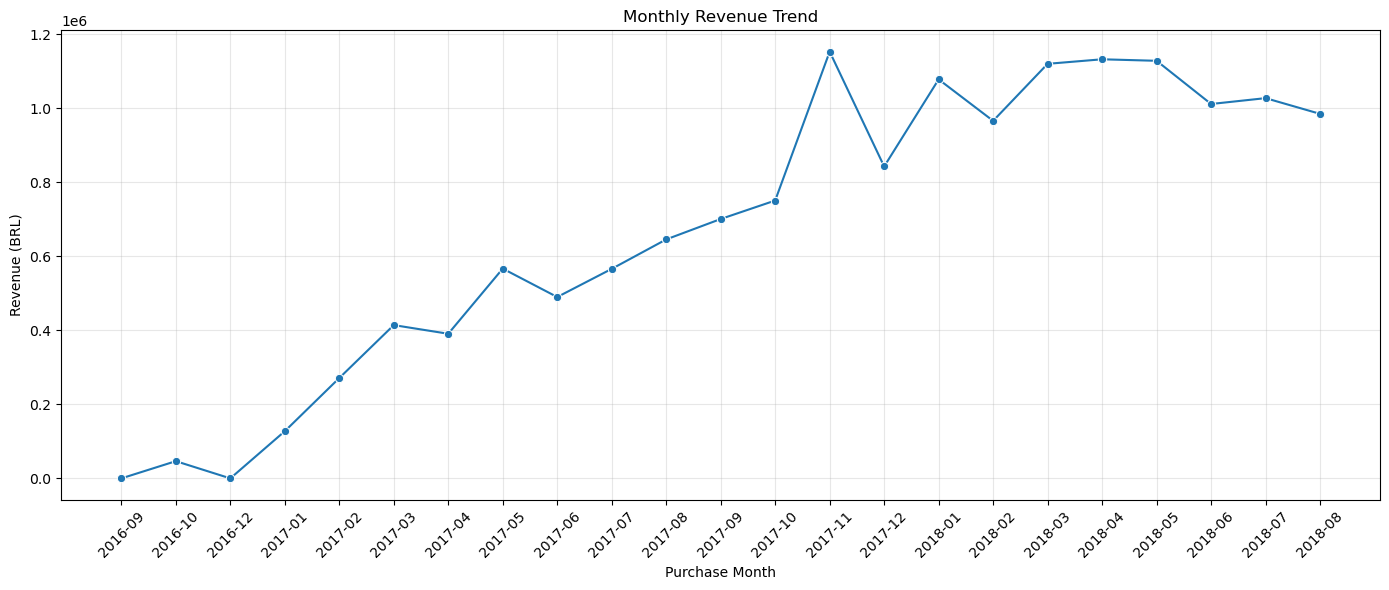

In [50]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_summary,
    x="purchase_month",
    y="total_revenue",
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Purchase Month")
plt.ylabel("Revenue (BRL)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

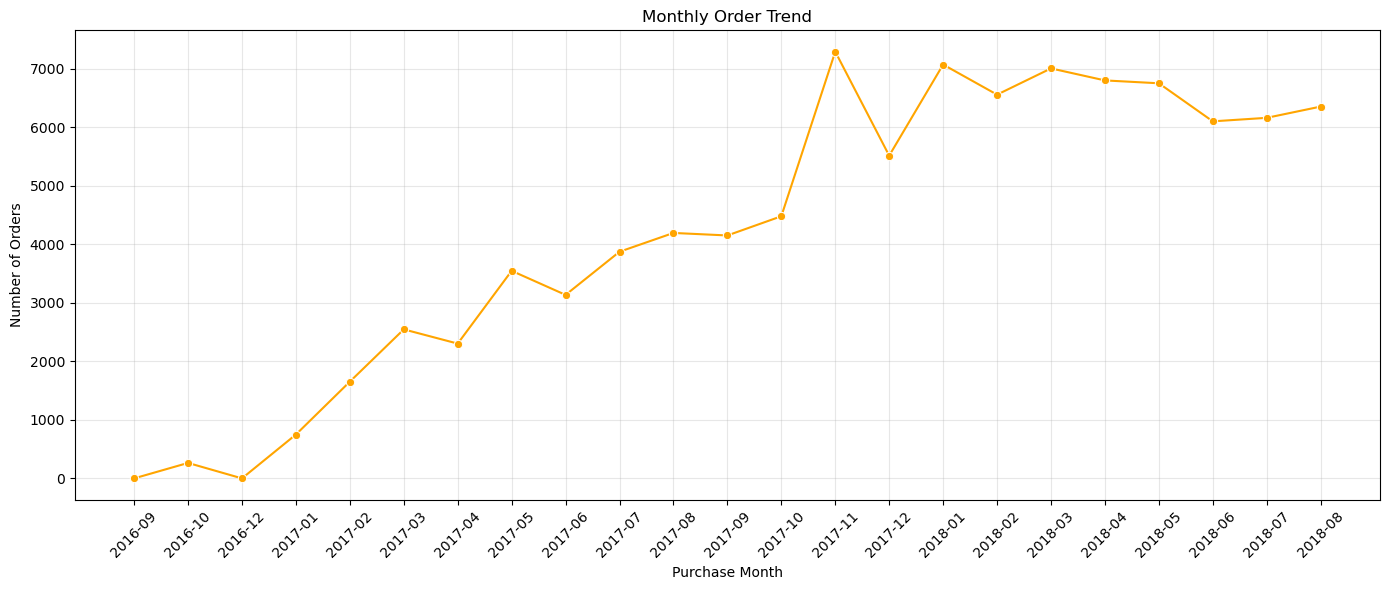

In [51]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_summary,
    x="purchase_month",
    y="total_orders",
    marker="o",
    color="orange"
)

plt.title("Monthly Order Trend")
plt.xlabel("Purchase Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

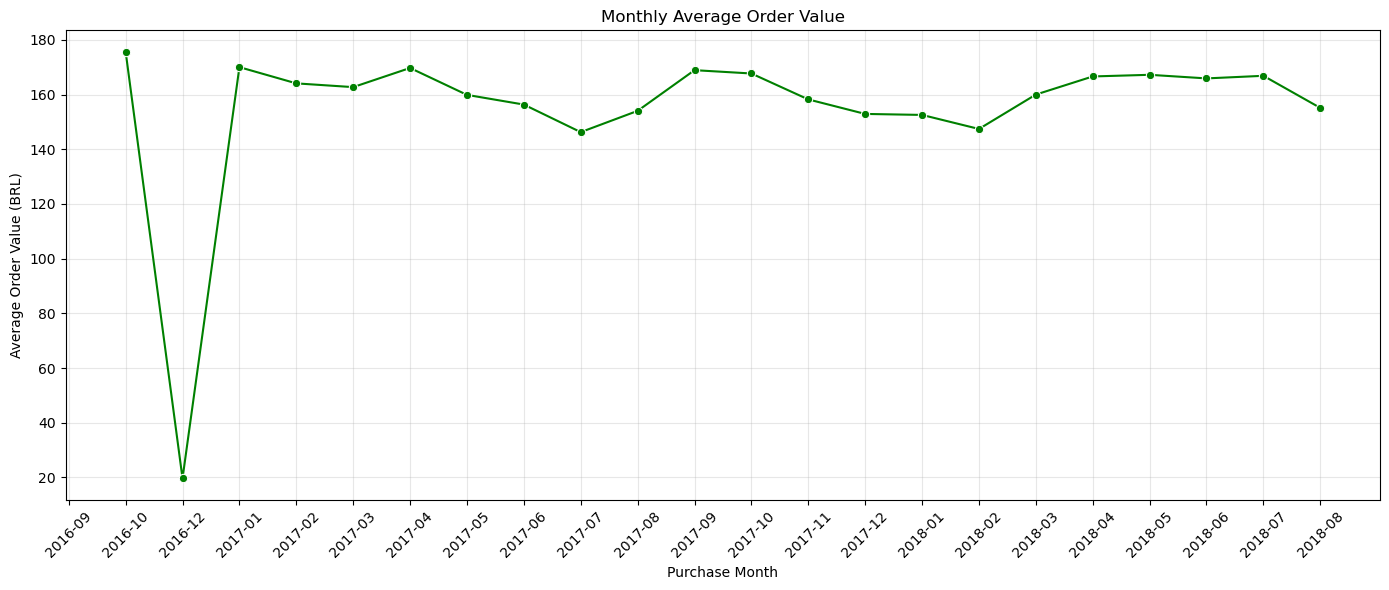

In [52]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_summary,
    x="purchase_month",
    y="average_order_value",
    marker="o",
    color="green"
)

plt.title("Monthly Average Order Value")
plt.xlabel("Purchase Month")
plt.ylabel("Average Order Value (BRL)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [53]:
monthly_summary.nlargest(
    5,
    "total_revenue"
)[
    [
        "purchase_month",
        "total_orders",
        "total_revenue",
        "average_order_value"
    ]
]

,purchase_month,total_orders,total_revenue,average_order_value
13,2017-11,7289,1153528.05,158.256009
18,2018-04,6798,1132933.95,166.656951
19,2018-05,6749,1128836.69,167.259844
17,2018-03,7003,1120678.00,160.028274
15,2018-01,7069,1078606.86,152.582665


In [54]:
correlation = monthly_summary[
    ["total_orders", "total_revenue"]
].corr()

correlation

,total_orders,total_revenue
total_orders,1.000000,0.996168
total_revenue,0.996168,1.000000


In [55]:
state_summary = (
    analysis_df
    .groupby("customer_state", as_index=False)
    .agg(
        total_orders=("order_id", "nunique"),
        unique_customers=("customer_unique_id", "nunique"),
        total_revenue=("total_payment_value", "sum"),
        average_order_value=("total_payment_value", "mean"),
        average_delivery_days=("delivery_time_days", "mean")
    )
    .sort_values("total_revenue", ascending=False)
)

state_summary.head(10)

,customer_state,total_orders,unique_customers,total_revenue,average_order_value,average_delivery_days
25,SP,40501,39156,5770266.19,142.475708,8.761386
18,RJ,12350,11917,2055690.45,166.452668,15.309438
10,MG,11354,11001,1819277.61,160.232307,12.008666
22,RS,5345,5168,861802.40,161.235248,15.300276
17,PR,4923,4769,781919.55,158.829890,11.991582
23,SC,3546,3449,595208.40,167.853469,14.954783
4,BA,3256,3158,591270.60,181.594165,19.335466
6,DF,2080,2019,346146.17,166.416428,12.967568
8,GO,1957,1895,334294.22,170.819734,15.606339
7,ES,1995,1928,317682.65,159.239424,15.789307


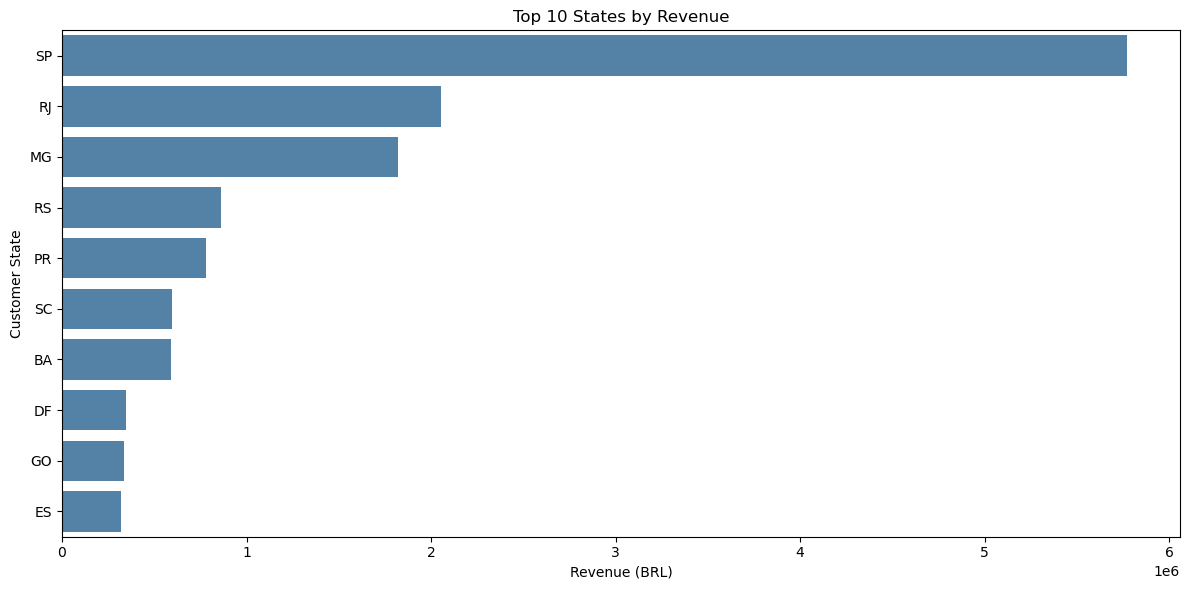

In [56]:
top_10_states = state_summary.head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_10_states,
    x="total_revenue",
    y="customer_state",
    color="steelblue"
)

plt.title("Top 10 States by Revenue")
plt.xlabel("Revenue (BRL)")
plt.ylabel("Customer State")
plt.tight_layout()
plt.show()

In [57]:
state_summary["revenue_share_percent"] = (
    state_summary["total_revenue"]
    / state_summary["total_revenue"].sum()
    * 100
)

state_summary[
    [
        "customer_state",
        "total_orders",
        "total_revenue",
        "revenue_share_percent",
        "average_order_value",
        "average_delivery_days"
    ]
].head(10)

,customer_state,total_orders,total_revenue,revenue_share_percent,average_order_value,average_delivery_days
25,SP,40501,5770266.19,37.414690,142.475708,8.761386
18,RJ,12350,2055690.45,13.329198,166.452668,15.309438
10,MG,11354,1819277.61,11.796285,160.232307,12.008666
22,RS,5345,861802.40,5.587969,161.235248,15.300276
17,PR,4923,781919.55,5.070005,158.829890,11.991582
23,SC,3546,595208.40,3.859361,167.853469,14.954783
4,BA,3256,591270.60,3.833828,181.594165,19.335466
6,DF,2080,346146.17,2.244429,166.416428,12.967568
8,GO,1957,334294.22,2.167580,170.819734,15.606339
7,ES,1995,317682.65,2.059870,159.239424,15.789307


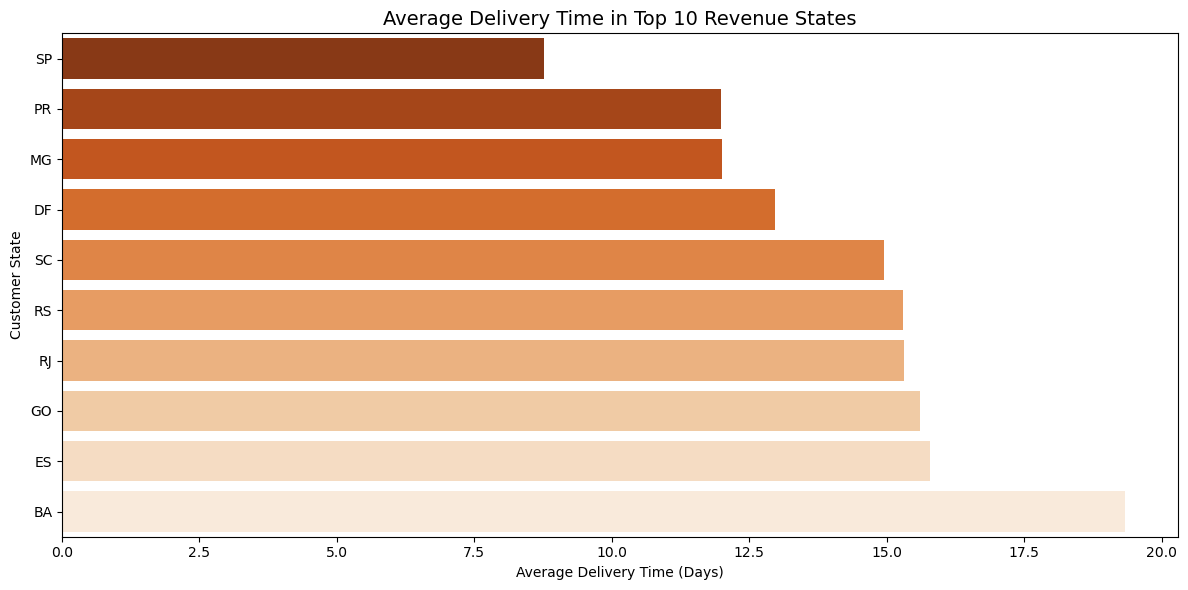

In [118]:
delivery_top_10 = top_10_states.sort_values(
    "average_delivery_days",
    ascending=True
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=delivery_top_10,
    x="average_delivery_days",
    y="customer_state",
    hue="customer_state",
    palette="Oranges_r",
    legend=False
)

plt.title("Average Delivery Time in Top 10 Revenue States", fontsize=14)
plt.xlabel("Average Delivery Time (Days)")
plt.ylabel("Customer State")
plt.tight_layout()
plt.show()

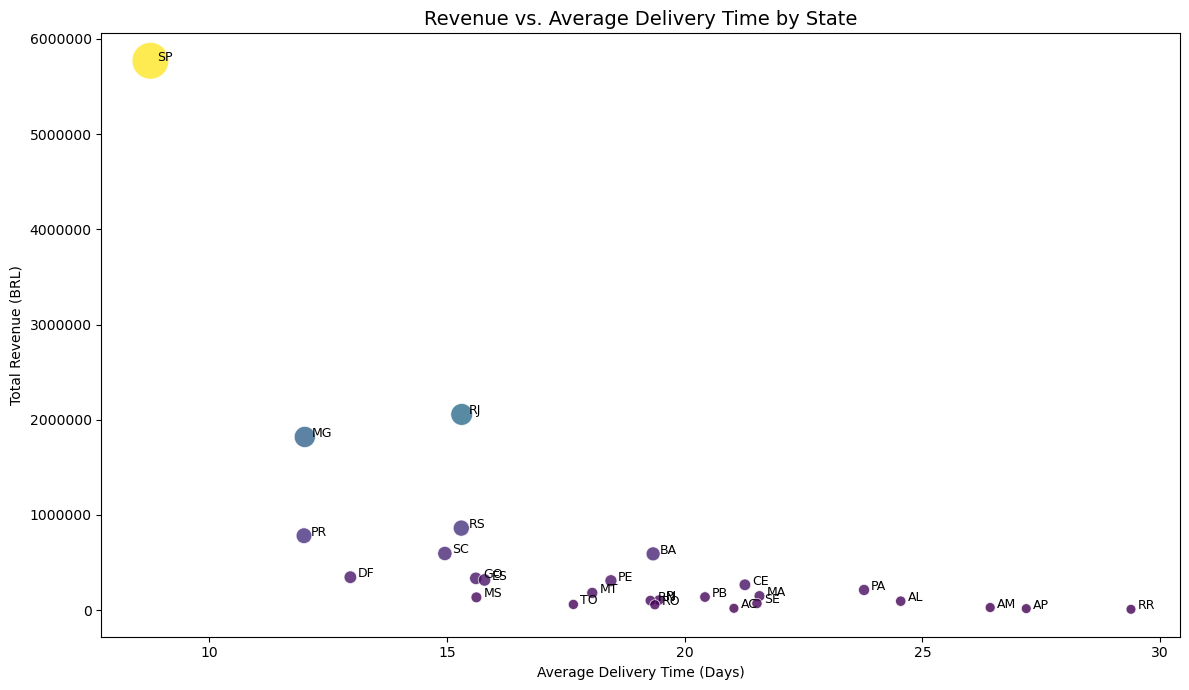

In [120]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=state_summary,
    x="average_delivery_days",
    y="total_revenue",
    size="total_orders",
    hue="total_revenue",
    palette="viridis",
    sizes=(50, 700),
    legend=False,
    alpha=0.8
)

for _, row in state_summary.iterrows():
    plt.text(
        row["average_delivery_days"] + 0.15,
        row["total_revenue"],
        row["customer_state"],
        fontsize=9
    )

plt.title("Revenue vs. Average Delivery Time by State", fontsize=14)
plt.xlabel("Average Delivery Time (Days)")
plt.ylabel("Total Revenue (BRL)")
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()

In [122]:
correlation_all = state_summary[
    ["average_delivery_days", "total_revenue"]
].corr().iloc[0, 1]

correlation_without_sp = state_summary[
    state_summary["customer_state"] != "SP"
][["average_delivery_days", "total_revenue"]].corr().iloc[0, 1]

print(f"Correlation for all states: {correlation_all:.3f}")
print(f"Correlation excluding SP: {correlation_without_sp:.3f}")

Correlation for all states: -0.600
Correlation excluding SP: -0.583


In [124]:
product_analysis = (
    order_items
    .merge(
        products[["product_id", "product_category_name"]],
        on="product_id",
        how="left"
    )
    .merge(
        category_translation,
        on="product_category_name",
        how="left"
    )
)

product_analysis.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,garden_tools


In [126]:
product_analysis["product_category_name_english"] = (
    product_analysis["product_category_name_english"]
    .fillna("Unknown")
)

category_summary = (
    product_analysis
    .groupby("product_category_name_english")
    .agg(
        total_orders=("order_id", "nunique"),
        items_sold=("order_item_id", "count"),
        total_revenue=("price", "sum"),
        average_product_price=("price", "mean")
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

category_summary.head(10)

,product_category_name_english,total_orders,items_sold,total_revenue,average_product_price
44,health_beauty,8836,9670,1258681.34,130.163531
71,watches_gifts,5624,5991,1205005.68,201.135984
8,bed_bath_table,9417,11115,1036988.68,93.296327
66,sports_leisure,7720,8641,988048.97,114.344285
16,computers_accessories,6689,7827,911954.32,116.513903
40,furniture_decor,6449,8334,729762.49,87.564494
21,cool_stuff,3632,3796,635290.85,167.357969
50,housewares,5884,6964,632248.66,90.788148
6,auto,3897,4235,592720.11,139.957523
43,garden_tools,3518,4347,485256.46,111.630196


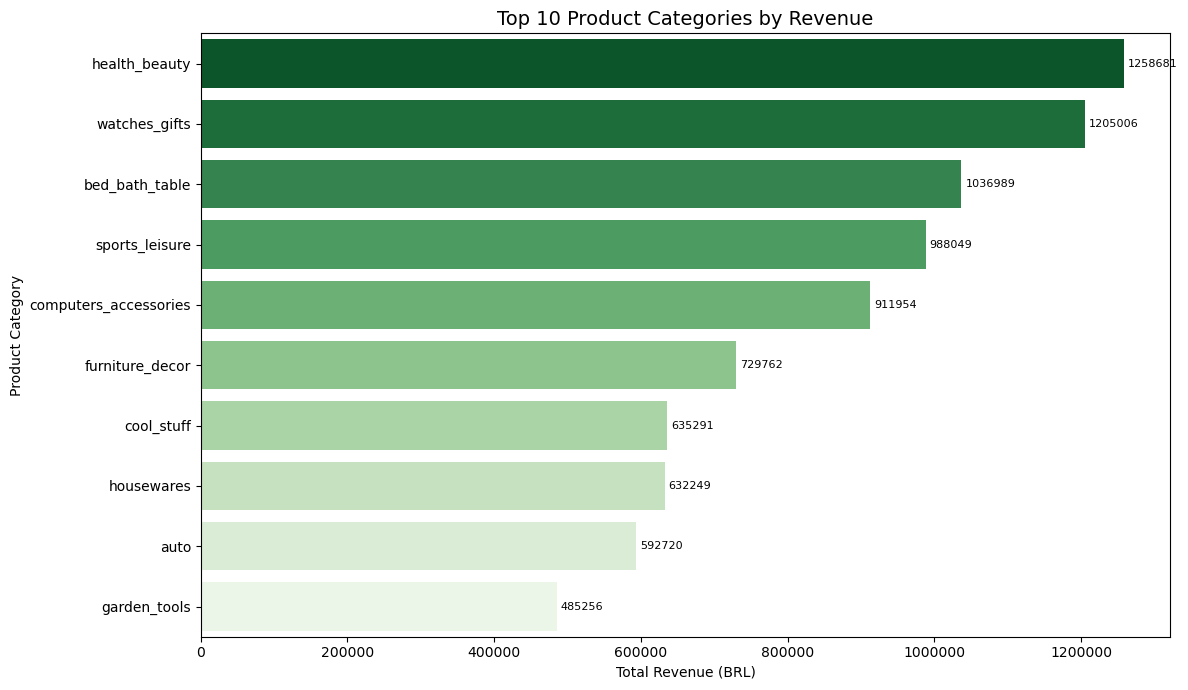

In [128]:
top_10_categories = category_summary.head(10).copy()

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=top_10_categories,
    x="total_revenue",
    y="product_category_name_english",
    hue="product_category_name_english",
    palette="Greens_r",
    legend=False
)

plt.title("Top 10 Product Categories by Revenue", fontsize=14)
plt.xlabel("Total Revenue (BRL)")
plt.ylabel("Product Category")
plt.ticklabel_format(style="plain", axis="x")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3,
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [130]:
customer_orders = (
    orders[orders["order_status"] == "delivered"]
    .merge(
        customers[["customer_id", "customer_unique_id"]],
        on="customer_id",
        how="left"
    )
)

customer_order_counts = (
    customer_orders
    .groupby("customer_unique_id")["order_id"]
    .nunique()
    .reset_index(name="number_of_orders")
)

total_customers = customer_order_counts["customer_unique_id"].nunique()

repeat_customers = (
    customer_order_counts["number_of_orders"] > 1
).sum()

repeat_purchase_rate = repeat_customers / total_customers * 100

print(f"Total customers: {total_customers:,}")
print(f"Repeat customers: {repeat_customers:,}")
print(f"Repeat purchase rate: {repeat_purchase_rate:.2f}%")

Total customers: 93,358
Repeat customers: 2,801
Repeat purchase rate: 3.00%


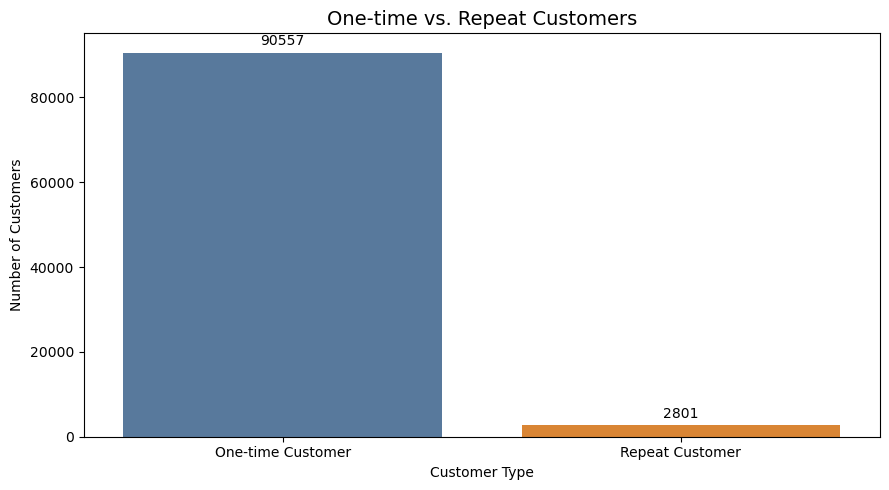

In [132]:
customer_type_summary = pd.DataFrame({
    "customer_type": ["One-time Customer", "Repeat Customer"],
    "number_of_customers": [
        total_customers - repeat_customers,
        repeat_customers
    ]
})

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=customer_type_summary,
    x="customer_type",
    y="number_of_customers",
    hue="customer_type",
    palette=["#4C78A8", "#F58518"],
    legend=False
)

plt.title("One-time vs. Repeat Customers", fontsize=14)
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

In [134]:
payment_summary = (
    payments[payments["payment_type"] != "not_defined"]
    .groupby("payment_type")
    .agg(
        total_payment_records=("order_id", "count"),
        total_orders=("order_id", "nunique"),
        total_payment_value=("payment_value", "sum"),
        average_payment_value=("payment_value", "mean")
    )
    .reset_index()
    .sort_values("total_orders", ascending=False)
)

payment_summary["order_share_percent"] = (
    payment_summary["total_orders"]
    / payment_summary["total_orders"].sum()
    * 100
)

payment_summary

,payment_type,total_payment_records,total_orders,total_payment_value,average_payment_value,order_share_percent
1,credit_card,76795,76505,12542084.19,163.319021,75.238732
0,boleto,19784,19784,2869361.27,145.034435,19.456546
3,voucher,5775,3866,379436.87,65.703354,3.802012
2,debit_card,1529,1528,217989.79,142.570170,1.502709


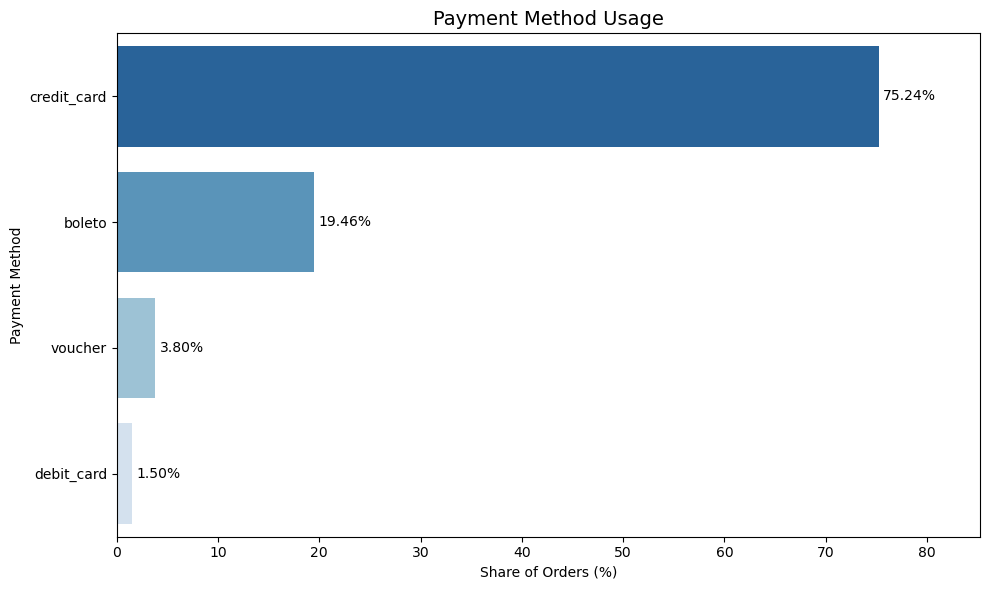

In [136]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=payment_summary,
    x="order_share_percent",
    y="payment_type",
    hue="payment_type",
    palette="Blues_r",
    legend=False
)

plt.title("Payment Method Usage", fontsize=14)
plt.xlabel("Share of Orders (%)")
plt.ylabel("Payment Method")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.xlim(0, payment_summary["order_share_percent"].max() + 10)
plt.tight_layout()
plt.show()

In [138]:

review_by_order = (
    reviews
    .groupby("order_id", as_index=False)
    .agg(review_score=("review_score", "mean"))
)

delivery_reviews = (
    orders[orders["order_status"] == "delivered"]
    .merge(
        review_by_order,
        on="order_id",
        how="inner"
    )
    .copy()
)


delivery_reviews["order_delivered_customer_date"] = pd.to_datetime(
    delivery_reviews["order_delivered_customer_date"],
    errors="coerce"
)

delivery_reviews["order_estimated_delivery_date"] = pd.to_datetime(
    delivery_reviews["order_estimated_delivery_date"],
    errors="coerce"
)


delivery_reviews = delivery_reviews.dropna(
    subset=[
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "review_score"
    ]
)


delivery_reviews["delay_days"] = (
    delivery_reviews["order_delivered_customer_date"]
    - delivery_reviews["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

delivery_reviews["delivery_status"] = np.where(
    delivery_reviews["delay_days"] <= 0,
    "On Time or Early",
    "Late"
)

delivery_review_summary = (
    delivery_reviews
    .groupby("delivery_status")
    .agg(
        total_orders=("order_id", "nunique"),
        average_review_score=("review_score", "mean")
    )
    .reset_index()
)

delay_review_correlation = delivery_reviews[
    ["delay_days", "review_score"]
].corr().iloc[0, 1]

display(delivery_review_summary)
print(
    f"Correlation between delivery delay and review score: "
    f"{delay_review_correlation:.3f}"
)

,delivery_status,total_orders,average_review_score
0,Late,7661,2.566506
1,On Time or Early,88163,4.294292


Correlation between delivery delay and review score: -0.267


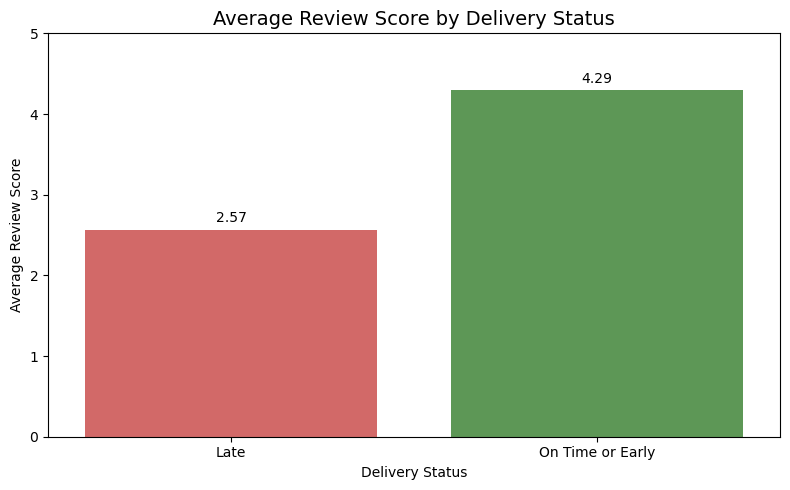

In [140]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=delivery_review_summary,
    x="delivery_status",
    y="average_review_score",
    hue="delivery_status",
    palette=["#E45756", "#54A24B"],
    legend=False
)

plt.title("Average Review Score by Delivery Status", fontsize=14)
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")
plt.ylim(0, 5)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )

plt.tight_layout()
plt.show()

In [142]:

delivered_order_ids = orders.loc[
    orders["order_status"] == "delivered",
    "order_id"
]

delivered_items = order_items[
    order_items["order_id"].isin(delivered_order_ids)
].copy()

seller_sales = (
    delivered_items
    .groupby("seller_id")
    .agg(
        total_orders=("order_id", "nunique"),
        items_sold=("order_item_id", "count"),
        total_revenue=("price", "sum")
    )
    .reset_index()
)


seller_order_reviews = (
    delivered_items[["seller_id", "order_id"]]
    .drop_duplicates()
    .merge(
        review_by_order,
        on="order_id",
        how="inner"
    )
)

seller_ratings = (
    seller_order_reviews
    .groupby("seller_id")
    .agg(
        average_review_score=("review_score", "mean"),
        reviewed_orders=("order_id", "nunique")
    )
    .reset_index()
)

seller_summary = seller_sales.merge(
    seller_ratings,
    on="seller_id",
    how="left"
)


high_revenue_threshold = seller_summary["total_revenue"].quantile(0.75)

high_sales_poor_rating = (
    seller_summary[
        (seller_summary["total_revenue"] >= high_revenue_threshold)
        & (seller_summary["average_review_score"] < 3.5)
        & (seller_summary["reviewed_orders"] >= 20)
    ]
    .sort_values("total_revenue", ascending=False)
)

print(f"High-revenue threshold: {high_revenue_threshold:,.2f} BRL")
print(f"Number of high-sales, poor-rating sellers: {len(high_sales_poor_rating)}")

high_sales_poor_rating.head(10)

High-revenue threshold: 3,497.88 BRL
Number of high-sales, poor-rating sellers: 24


,seller_id,total_orders,items_sold,total_revenue,average_review_score,reviewed_orders
1480,7c67e1448b00f6e969d365cea6b010ab,973,1355,186570.05,3.495863,967.0
1336,712e6ed8aa4aa1fa65dab41fed5737e4,77,85,39385.00,3.394737,76.0
540,2eb70248d66e0e3ef83659f71b244378,187,197,38990.72,2.790761,184.0
1606,88460e8ebdecbfecb5f9601833981930,246,300,31320.40,3.442857,245.0
1334,710e3548e02bc1d2831dfc4f1b5b14d4,131,137,22369.25,3.430769,130.0
1566,8444e55c1f13cd5c179851e5ca5ebd00,92,102,21480.96,3.369565,92.0
1543,821fb029fc6e495ca4f08a35d51e53a5,24,25,17851.62,3.478261,23.0
139,0b35c634521043bf4b47e21547b99ab5,50,77,13235.65,3.408163,49.0
323,1ca7077d890b907f89be8c954a02686a,108,127,12474.64,2.392523,107.0
1962,a7f13822ceb966b076af67121f87b063,73,84,12017.69,3.402778,72.0


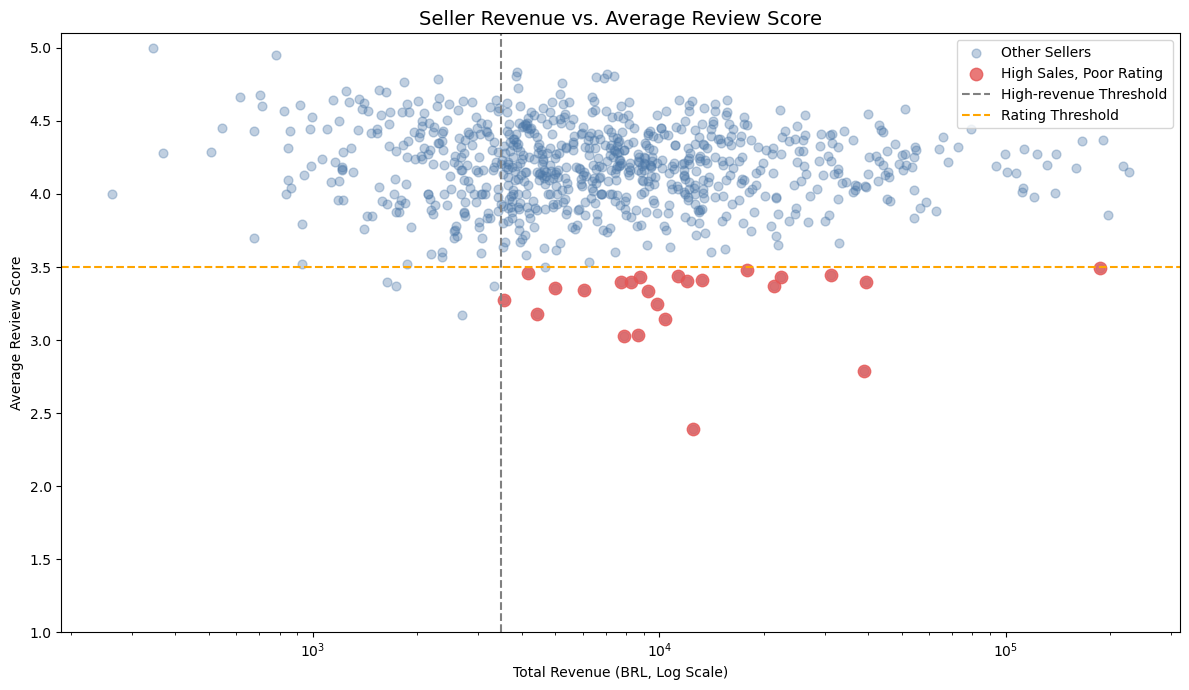

In [144]:
seller_plot_data = seller_summary[
    seller_summary["reviewed_orders"] >= 20
].dropna(subset=["average_review_score"])

plt.figure(figsize=(12, 7))

plt.scatter(
    seller_plot_data["total_revenue"],
    seller_plot_data["average_review_score"],
    s=40,
    alpha=0.35,
    color="#4C78A8",
    label="Other Sellers"
)

plt.scatter(
    high_sales_poor_rating["total_revenue"],
    high_sales_poor_rating["average_review_score"],
    s=80,
    alpha=0.8,
    color="#E45756",
    label="High Sales, Poor Rating"
)

plt.axvline(
    high_revenue_threshold,
    color="gray",
    linestyle="--",
    label="High-revenue Threshold"
)

plt.axhline(
    3.5,
    color="orange",
    linestyle="--",
    label="Rating Threshold"
)

plt.xscale("log")
plt.title("Seller Revenue vs. Average Review Score", fontsize=14)
plt.xlabel("Total Revenue (BRL, Log Scale)")
plt.ylabel("Average Review Score")
plt.ylim(1, 5.1)
plt.legend()
plt.tight_layout()
plt.show()

In [150]:
from pathlib import Path

output_path = Path(
    r"C:\Users\GIA NGUYEN\OneDrive\Máy tính\Ecommerce_Olist_Analysis\data\processed"
)

output_path.mkdir(parents=True, exist_ok=True)

state_summary.to_csv(output_path / "state_summary.csv", index=False)
category_summary.to_csv(output_path / "category_summary.csv", index=False)
customer_order_counts.to_csv(
    output_path / "customer_order_counts.csv",
    index=False
)
payment_summary.to_csv(output_path / "payment_summary.csv", index=False)

delivery_reviews[
    ["order_id", "review_score", "delay_days", "delivery_status"]
].to_csv(
    output_path / "delivery_review_analysis.csv",
    index=False
)

seller_summary.to_csv(
    output_path / "seller_summary.csv",
    index=False
)

print("Đã lưu tại:", output_path)

for file in output_path.glob("*.csv"):
    print(file.name)

Đã lưu tại: C:\Users\GIA NGUYEN\OneDrive\Máy tính\Ecommerce_Olist_Analysis\data\processed
category_summary.csv
customer_order_counts.csv
delivery_review_analysis.csv
payment_summary.csv
seller_summary.csv
state_summary.csv
